<a href="https://colab.research.google.com/github/KrishViradiya/group8_hadoop_mapReduce/blob/main/Semantic_Clustering%20%26%20Evaluation/Harsh_Savani/HarshDS4SE26Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# @title
!unzip hadoop-trunk.zip

Streaming output truncated to the last 5000 lines.
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/View.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/WebApp.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/WebAppException.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/WebApps.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/YarnJacksonJaxbJsonProvider.java  
  inflating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/hadoop/yarn/webapp/YarnWebParams.java  
   creating: hadoop-trunk/hadoop-yarn-project/hadoop-yarn/hadoop-yarn-common/src/main/java/org/apache/h

In [14]:
import numpy as np
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path
from google.colab import userdata

**1. Provide the path of java files and load their source code into a list**

In [15]:
from pathlib import Path

SOURCE_CODE_DIR = Path("/content/hadoop-trunk/hadoop-mapreduce-project/hadoop-mapreduce-client/hadoop-mapreduce-client-core/src/main/java/org/apache/hadoop/mapreduce")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
files_list = []
# Reloading files from the MapReduce directory
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [17]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [18]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [19]:
# 1. Install dependencies.
# IMPORTANT: Restart session (Runtime > Restart session) after this finishes.
!pip install -U bitsandbytes>=0.46.1 accelerate

**4. Generate embeddings**

In [20]:
embedding_model_name = "ibm-granite/granite-embedding-english-r2"

In [21]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name, token=hf_token)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # Attempting 4-bit loading
    model = AutoModel.from_pretrained(
        embedding_model_name,
        token=hf_token,
        quantization_config=bnb_config,
        device_map="auto"
    )
    print("Model loaded successfully with 4-bit quantization.")
except Exception as e:
    print(f"Quantization failed or bitsandbytes not found: {e}")
    print("Falling back to standard loading...")
    model = AutoModel.from_pretrained(embedding_model_name, token=hf_token)
    model.to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

Model loaded successfully with 4-bit quantization.


**5. Construct the semantic similarity matrix**

In [22]:
def embed_source_code(code_files):
    embeddings = []
    # Ensure model is in eval mode and correct dtype
    model.eval()

    for code in code_files:
        # Max length 512
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            # We force the model to compute in float32 if on CPU or if BFloat16 is unsupported
            outputs = model(**inputs)
            # Take the mean of the token embeddings
            # Ensure we are working with float32 for the mean calculation to avoid the BFloat16 error
            code_embedding = outputs.last_hidden_state.to(torch.float32).mean(dim=1).squeeze().cpu().numpy()
        embeddings.append(code_embedding)
    return np.array(embeddings)

In [23]:
print(f"Number of files found: {len(files_list)}")

Number of files found: 332


In [24]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Initialize with zeros to prevent NameErrors in later cells
global semantic_matrix
semantic_matrix = np.zeros((len(files_list), len(files_list)))

# Check if function exists in globals
if 'embed_source_code' in globals() and len(files_list) > 0:
    print(f"Generating embeddings for {len(files_list)} files...")
    try:
        embeddings_array = embed_source_code(files_list)
        if embeddings_array is not None and len(embeddings_array) > 0:
            semantic_matrix = cosine_similarity(embeddings_array)
            print(f"Semantic similarity matrix constructed: {semantic_matrix.shape}")
    except Exception as e:
        print(f"Error during embedding generation: {e}")
else:
    print("CRITICAL: 'embed_source_code' function not found. Please ensure you have executed cell k3zp8OnDD4re before running this cell.")

Generating embeddings for 332 files...


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
W0516 20:26:17.939000 5037 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


Semantic similarity matrix constructed: (332, 332)


**6. Construct the structural similarity matrix**

In [25]:
import re
import numpy as np
from pathlib import Path

def get_full_class_name(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        package_match = re.search(r'^\s*package\s+([^;]+);', content, re.MULTILINE)
        package = package_match.group(1).strip() if package_match else ""
        class_name = Path(file_path).stem
        return f"{package}.{class_name}" if package else class_name

full_class_names = [get_full_class_name(p) for p in SOURCE_CODE_DIR.rglob('*.java') if p.is_file()]
num_files = len(full_class_names)
struct_matrix_raw = np.zeros((num_files, num_files))

dependencies = {}
rsf_path = "/content/mapreduce_filtered.rsf"

if not Path(rsf_path).exists():
    print(f"CRITICAL ERROR: {rsf_path} not found. Please upload the RSF file to the /content/ folder.")
else:
    try:
        with open(rsf_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3 and parts[0] == 'depends':
                    source, target = parts[1], parts[2]
                    if source not in dependencies: dependencies[source] = set()
                    dependencies[source].add(target)

        for i in range(num_files):
            for j in range(i, num_files):
                set_i = dependencies.get(full_class_names[i], set())
                set_j = dependencies.get(full_class_names[j], set())
                common_count = len(set_i.intersection(set_j))
                struct_matrix_raw[i, j] = struct_matrix_raw[j, i] = common_count

        print(f"Structural matrix constructed. Shape: {struct_matrix_raw.shape}")
        print(f"Max overlap found: {struct_matrix_raw.max()}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Structural matrix constructed. Shape: (332, 332)
Max overlap found: 38.0


**7. Normalize the structural matrix**

In [26]:
# Normalizing the structural matrix to a 0-1 range
max_overlap = struct_matrix_raw.max()
if max_overlap > 0:
    struct_matrix = struct_matrix_raw / max_overlap
else:
    struct_matrix = struct_matrix_raw

# Diagonals represent a file's similarity to itself, which is always 1.0
np.fill_diagonal(struct_matrix, 1.0)

print(f"Structural matrix normalized. Max value: {struct_matrix.max()}")

Structural matrix normalized. Max value: 1.0


**8. Combine the two matrices into one similarity matrix then apply complement.**

In [27]:
# ALPHA dictates the weight of structural vs. semantic data.
# 0.5 gives equal weight to both dependency structure and code meaning.
ALPHA = 0.5
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance (Clustering algorithms use distance)
distance_matrix = 1.0 - combined_similarity

# Ensure diagonal is exactly 0 (distance to self)
np.fill_diagonal(distance_matrix, 0)

print("Combined distance matrix calculated successfully.")

Combined distance matrix calculated successfully.


**9. Apply clustering**

In [28]:
print(distance_matrix)

[[0.         0.63427263 0.61865123 ... 0.62936503 0.63169724 0.62676385]
 [0.63427263 0.         0.6036368  ... 0.62033665 0.62895358 0.6094377 ]
 [0.61865123 0.6036368  0.         ... 0.62355375 0.63409591 0.60073495]
 ...
 [0.62936503 0.62033665 0.62355375 ... 0.         0.5214746  0.55812269]
 [0.63169724 0.62895358 0.63409591 ... 0.5214746  0.         0.58196276]
 [0.62676385 0.6094377  0.60073495 ... 0.55812269 0.58196276 0.        ]]


In [29]:
# Final clustering for Week 3
TARGET_NUM_CLUSTERS = 10
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete')
clusters = clusterer.fit_predict(distance_matrix)

print(f"Clustering complete! {len(clusters)} MapReduce files grouped into {TARGET_NUM_CLUSTERS} clusters.")

Clustering complete! 332 MapReduce files grouped into 10 clusters.


**10. Visulizations**

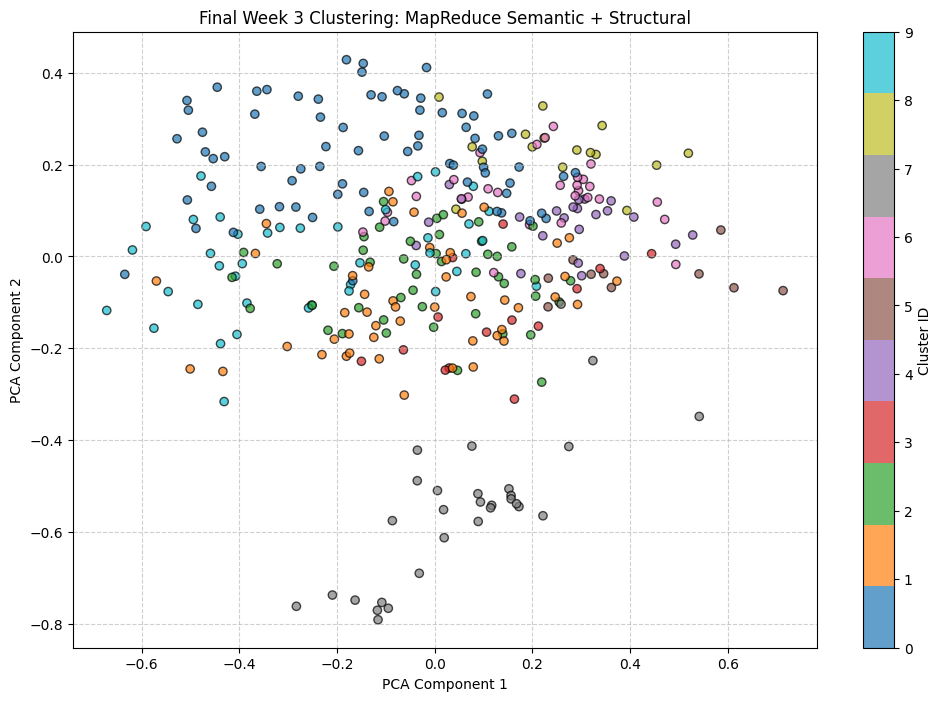

In [30]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Visualization using PCA to project the combined distance matrix into 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(distance_matrix)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='tab10', alpha=0.7, edgecolors='k')
plt.title('Final Week 3 Clustering: MapReduce Semantic + Structural')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

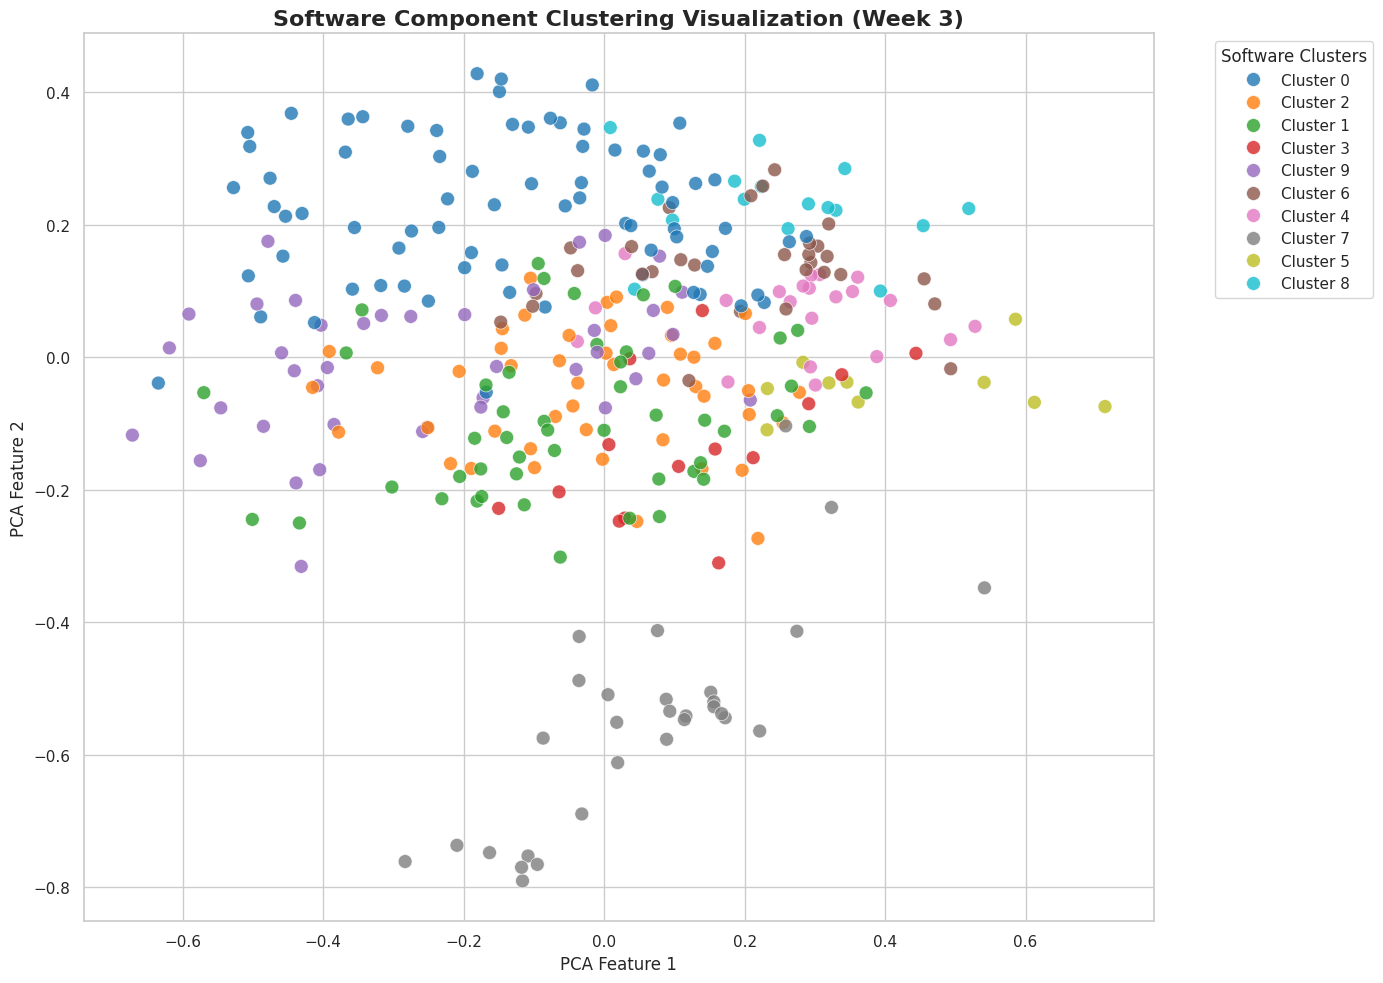

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a more readable dataframe for plotting
plot_df = pd.DataFrame({
    'x': reduced_data[:, 0],
    'y': reduced_data[:, 1],
    'Cluster': [f'Cluster {c}' for c in clusters]
})

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 10))

# Create the scatter plot with a legend
scatter_plot = sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='Cluster',
    palette='tab10',
    s=100,
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Software Component Clustering Visualization (Week 3)', fontsize=16, fontweight='bold')
plt.xlabel('PCA Feature 1', fontsize=12)
plt.ylabel('PCA Feature 2', fontsize=12)

# Move legend to the side for better visibility
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Software Clusters')

plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

# Aligning lengths to avoid ValueError
min_length = min(len(full_class_names), len(clusters))

# Create a mapping of File Name to Cluster ID
results_df = pd.DataFrame({
    'Full_Class_Name': full_class_names[:min_length],
    'Cluster_ID': clusters[:min_length]
})

# Save to the output directory
output_file = OUTPUT_DIR / "clustering_results.csv"
results_df.to_csv(output_file, index=False)

print(f"Results saved to: {output_file}")
print(f"Aligned to {min_length} files.")
display(results_df.head())

Results saved to: /content/output/clustering_results.csv
Aligned to 332 files.


,Full_Class_Name,Cluster_ID
0,org.apache.hadoop.mapreduce.ContextFactory,0
1,org.apache.hadoop.mapreduce.TaskCounter,2
2,org.apache.hadoop.mapreduce.OutputCommitter,1
3,org.apache.hadoop.mapreduce.TaskReport,3
4,org.apache.hadoop.mapreduce.RecordReader,0


In [33]:
# Define the output path for the RSF file
rsf_output_path = OUTPUT_DIR / "final_clustering_using_ibm-granite.rsf"

# Open file and write clustering results in RSF format
# Format: contain <Cluster_ID> <Full_Class_Name>
with open(rsf_output_path, 'w') as f:
    for _, row in results_df.iterrows():
        f.write(f"contain Cluster_{row['Cluster_ID']} {row['Full_Class_Name']}\n")

print(f"RSF file generated successfully at: {rsf_output_path}")

# Display the first few lines of the generated RSF
!head -n 5 {rsf_output_path}

RSF file generated successfully at: /content/output/final_clustering_using_ibm-granite.rsf
contain Cluster_0 org.apache.hadoop.mapreduce.ContextFactory
contain Cluster_2 org.apache.hadoop.mapreduce.TaskCounter
contain Cluster_1 org.apache.hadoop.mapreduce.OutputCommitter
contain Cluster_3 org.apache.hadoop.mapreduce.TaskReport
contain Cluster_0 org.apache.hadoop.mapreduce.RecordReader


### Experiment: Adjust Hyperparameters
Use this cell to tweak the balance between structure and semantics, or change the granularity of the clusters.

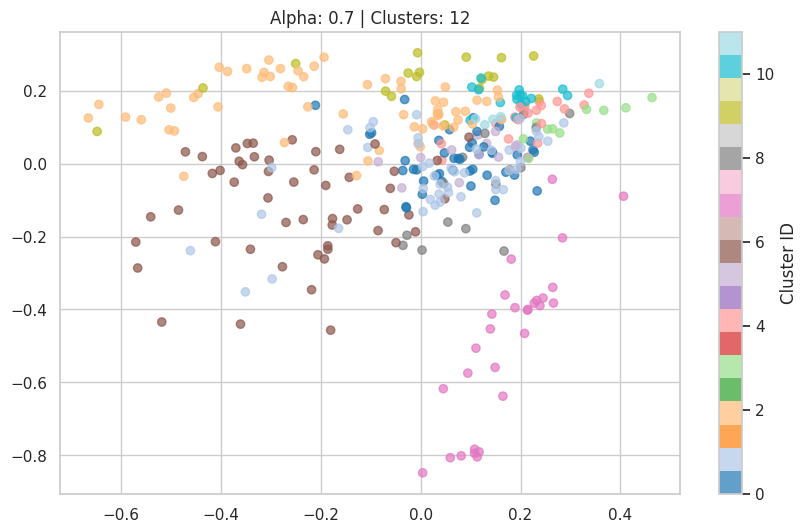

In [34]:
# @title Clustering Experimentation { run: "auto" }
NEW_ALPHA = 0.7 # @param {type:"slider", min:0, max:1, step:0.1}
NEW_TARGET_CLUSTERS = 12 # @param {type:"slider", min:2, max:30, step:1}

# 1. Re-calculate distance matrix
combined_sim = (NEW_ALPHA * struct_matrix) + ((1 - NEW_ALPHA) * semantic_matrix)
dist_mat = 1.0 - combined_sim
np.fill_diagonal(dist_mat, 0)

# 2. Re-cluster
new_clusterer = AgglomerativeClustering(n_clusters=NEW_TARGET_CLUSTERS, metric='precomputed', linkage='complete')
new_clusters = new_clusterer.fit_predict(dist_mat)

# 3. Visualize the change
pca = PCA(n_components=2)
coords = pca.fit_transform(dist_mat)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=new_clusters, cmap='tab20', alpha=0.7)
plt.title(f'Alpha: {NEW_ALPHA} | Clusters: {NEW_TARGET_CLUSTERS}')
plt.colorbar(label='Cluster ID')
plt.show()

## Automated Multi-Model & Hyperparameter Evaluation
This section automates the generation of results for both IBM Granite and Jina AI models across a range of Alpha and Cluster parameters.

In [41]:
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

# --- Configuration ---
MODELS = ["ibm-granite/granite-embedding-english-r2", "jinaai/jina-code-embeddings-0.5b"]
ALPHAS = [0.3, 0.5, 0.7]
CLUSTERS_LIST = [8, 12, 16]
BASE_OUTPUT = Path("/content/experiment_results")

def run_full_pipeline():
    if BASE_OUTPUT.exists():
        shutil.rmtree(BASE_OUTPUT)

    for model_name in MODELS:
        print(f"\n>>> Processing Model: {model_name}")
        current_tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
        current_model = AutoModel.from_pretrained(model_name, token=hf_token, trust_remote_code=True).to(device)
        current_model.eval()

        embeddings = []
        for code in files_list:
            inputs = current_tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
            with torch.no_grad():
                out = current_model(**inputs)
                emb = out.last_hidden_state.to(torch.float32).mean(dim=1).squeeze().cpu().numpy()
            embeddings.append(emb)
        current_semantic_matrix = cosine_similarity(np.array(embeddings))

        for alpha in ALPHAS:
            for n_clusters in CLUSTERS_LIST:
                run_dir = BASE_OUTPUT / model_name.split('/')[-1] / f"alpha_{alpha}_clusters_{n_clusters}"
                run_dir.mkdir(parents=True, exist_ok=True)

                sim = (alpha * struct_matrix) + ((1 - alpha) * current_semantic_matrix)
                dist = 1.0 - sim
                np.fill_diagonal(dist, 0)

                algo = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='complete')
                labels = algo.fit_predict(dist)

                # Save CSV and RSF
                df_res = pd.DataFrame({'Class': full_class_names, 'Cluster': labels})
                df_res.to_csv(run_dir / "results.csv", index=False)
                with open(run_dir / "output.rsf", 'w') as f:
                    for _, row in df_res.iterrows():
                        f.write(f"contain Cluster_{row['Cluster']} {row['Class']}\n")

                # Visualization with proper Legend using Seaborn
                pca_coords = PCA(n_components=2).fit_transform(dist)
                viz_df = pd.DataFrame({'PCA 1': pca_coords[:,0], 'PCA 2': pca_coords[:,1], 'Cluster': [f"C{l}" for l in labels]})

                plt.figure(figsize=(12, 8))
                sns.set_style("whitegrid")
                plot = sns.scatterplot(data=viz_df, x='PCA 1', y='PCA 2', hue='Cluster', palette='tab20', alpha=0.8, edgecolors='k')

                plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clusters')
                plt.title(f"{model_name}\nAlpha: {alpha} | Clusters: {n_clusters}")
                plt.savefig(run_dir / "visualization.png", bbox_inches='tight')
                plt.close()

                print(f"   Saved: Alpha {alpha}, Clusters {n_clusters}")

run_full_pipeline()
print(f"\nPipeline complete. Files are in: {BASE_OUTPUT}")


>>> Processing Model: ibm-granite/granite-embedding-english-r2


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

   Saved: Alpha 0.3, Clusters 8
   Saved: Alpha 0.3, Clusters 12
   Saved: Alpha 0.3, Clusters 16
   Saved: Alpha 0.5, Clusters 8
   Saved: Alpha 0.5, Clusters 12
   Saved: Alpha 0.5, Clusters 16
   Saved: Alpha 0.7, Clusters 8
   Saved: Alpha 0.7, Clusters 12
   Saved: Alpha 0.7, Clusters 16

>>> Processing Model: jinaai/jina-code-embeddings-0.5b


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

   Saved: Alpha 0.3, Clusters 8
   Saved: Alpha 0.3, Clusters 12
   Saved: Alpha 0.3, Clusters 16
   Saved: Alpha 0.5, Clusters 8
   Saved: Alpha 0.5, Clusters 12
   Saved: Alpha 0.5, Clusters 16
   Saved: Alpha 0.7, Clusters 8
   Saved: Alpha 0.7, Clusters 12
   Saved: Alpha 0.7, Clusters 16

Pipeline complete. Files are in: /content/experiment_results


### Download Experiment Results
Run the cell below to package all generated files into a ZIP archive and download it to your local machine.

In [42]:
from google.colab import files
import shutil

# Define the name for the zip file
zip_filename = "clustering_experiment_results"

# Create a zip archive of the results folder
shutil.make_archive(zip_filename, 'zip', BASE_OUTPUT)

# Trigger the download
files.download(f"{zip_filename}.zip")
print(f"Created and downloading {zip_filename}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created and downloading clustering_experiment_results.zip
